In [ ]:
import earthkit.data as ekd
import earthkit.plots as ekp
import earthkit.transforms as ekt
import earthkit.geo as ekg
import earthkit.meteo as ekm
import earthkit.hydro as ekh
import numpy as np

# Basic Idea

Conduct an analysis of the water balance for a catchment where we also have observations.

Basic idea: water balance equation

$ P = Q + ET \pm \Delta S$

Precipitation = Runoff + Evapotranspiration + Changes in Storage

Investigate this relationship for some of our data.
- earthkit-data to load data from CDS
- earthkit-geo to regrid onto a river network grid
- earthkit-hydro to do catchment averaging
- earthkit-transforms to do temporal aggregations to daily
- earthkit-meteo to help compute evaporation (note: variable is actually available directly, but this is to show off earthkit)
- earthkit-plots for pretty visualisations

# earthkit-data

In [ ]:
YEARS  = ["2025"]
MONTHS = [f"{m:02d}" for m in range(5, 6)]
DAYS   = [f"{d:02d}" for d in range(1, 10)]   # CDS ignores days that don't exist in the month

CDS_REQUEST = dict(
    product_type="reanalysis",
    grid=[1, 1],
    year=YEARS,
    month=MONTHS,
    day=DAYS,
    time=[f"{h:02d}:00" for h in range(24)],
    variable=[
        "2m_temperature",                # t2m  – K
        "2m_dewpoint_temperature",       # d2m  – K
        "10m_u_component_of_wind",       # u10  – m/s
        "10m_v_component_of_wind",       # v10  – m/s
        "surface_net_solar_radiation",   # ssr – J/m² accumulated per step
        "surface_net_thermal_radiation", # str – J/m² accumulated per step
        "evaporation",                   # e – m accumulated per step
        "total_precipitation",           # tp – m accumulated per step
    ],
)

# this takes 6 mins so we might want to reduce
ds = ekd.from_source("cds", "reanalysis-era5-single-levels", request=CDS_REQUEST)

2026-04-30 09:40:45,712 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)
2026-04-30 09:40:45,714 INFO Request ID is e6037a66-912e-4c15-9d32-04785d8709c7
2026-04-30 09:40:45,788 INFO status has been updated to accepted
2026-04-30 09:40:59,302 INFO status has been updated to running
2026-04-30 09:42:39,787 INFO status has been updated to successful


# earthkit-geo

In [42]:
gridspec = {
        'grid': [15/60, 15/60],
        'area': [
            89.875,
            -179.875,
            -89.875,
            179.875
            ]
        }

In [ ]:
fields = []
for field in ds.to_fieldlist():
    # conservative interpolation
    if field.get("parameter.variable") in ["e", "ssr", 'str', 'tp']:
        regrided_field = ekg.regrid(field, gridspec, interpolation="grid-box-average")
    # linear interpolation
    else:
        regrided_field = ekg.regrid(field, gridspec, interpolation="linear")
    fields.append(regrided_field)

ds_cama_15min = ekd.FieldList.from_fields(fields)

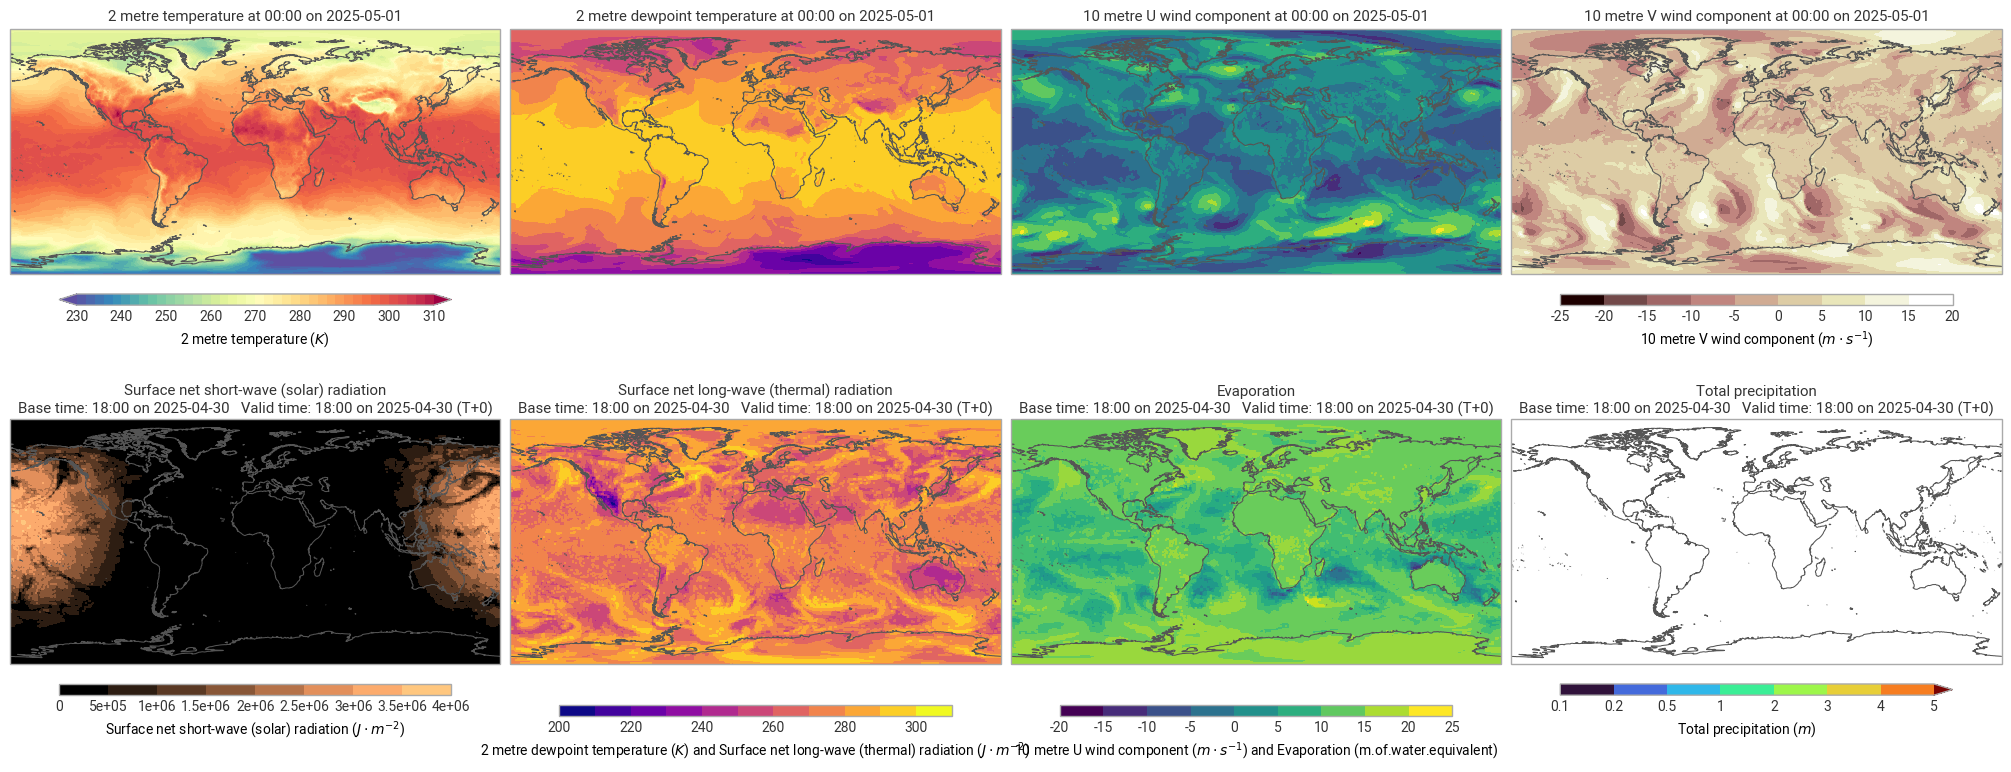

In [ ]:
ekp.geo.plot(ds_cama_15min.sel({"time.valid_datetime": "2025-05-01"}))

In [ ]:
xr_ds = ds_cama_15min.to_xarray(time_dims=["valid_time"])

# earthkit-hydro

In [46]:
net = ekh.river_network.load("cama_15min", "4", use_cache=False)

Cache disabled.
Cache disabled.


In [47]:
locations = {
    "Rhine at Basel": (47.56, 7.59)
    }
xr_ds_catchment = ekh.catchments.mean(net, xr_ds, locations)

# earthkit-transforms

In [48]:
daily_avg_ds = ekt.temporal.daily_mean(xr_ds_catchment)
daily_max_2t = ekt.temporal.daily_max(daily_avg_ds["2t"])
daily_min_2t = ekt.temporal.daily_min(daily_avg_ds["2t"])

daily_ds = daily_avg_ds
daily_ds["2t_max"] = daily_max_2t
daily_ds["2t_min"] = daily_min_2t

# Reference Evapotranspiration (ET₀) via Penman–Monteith (FAO-56)

This notebook computes **daily reference evapotranspiration ET₀** for the Rhine
catchment at Basel using the **FAO-56 Penman–Monteith** equation and ERA5 hourly
meteorological fields.

## FAO-56 Penman–Monteith equation

$$
ET_0 = \frac{0.408\,\Delta\,(R_n - G)
       + \gamma\,\frac{900}{T+273}\,u_2\,(e_s - e_a)}
      {\Delta + \gamma\,(1 + 0.34\,u_2)}
\quad [\text{mm day}^{-1}]
$$

> **Note:** ET₀ represents the evaporative demand of the atmosphere for a hypothetical
> well-watered reference grass canopy.  It differs from *actual* evapotranspiration,
> which is limited by soil moisture and canopy resistance.


# earthkit-meteo

In [ ]:
from earthkit.meteo import thermo, wind
import numpy as np

t_air = daily_avg_ds["2t"] # K
gamma = 0.66 # approximately constant
u_10 = wind.speed(daily_avg_ds["10u"], daily_avg_ds["10v"]) # m/s
u_2 = u_10 * 4.87 / np.log(67.8 * 10 - 5.42) # m/s, using logarithmic wind profile to estimate 2m wind speed from 10m wind speed
delta = thermo.saturation_vapour_pressure_slope(daily_avg_ds["2t"]) / 1000 # kPa/K
R_n = ekt.temporal.daily_sum(xr_ds_catchment["ssr"] + xr_ds_catchment["str"]) * 1e-6 # convert from J/m^2 to MJ/m^2/day
G = 0 # MJ/m^2, assuming negligible ground heat flux, valid approximation only for daily steps

e_Tmax = thermo.saturation_vapour_pressure(daily_max_2t) / 1000 # kPa
e_Tmin = thermo.saturation_vapour_pressure(daily_min_2t) / 1000 # kPa
e_s = 0.5 * (e_Tmax + e_Tmin) / 1000 # kPa, average saturation vapour pressure
e_a = thermo.saturation_vapour_pressure(daily_avg_ds["2d"]) / 1000 # kPa, actual vapour pressure from dew point temperature
delta_e = (e_s - e_a) # kPa

# the signage of the energy budget components needs to be adjusted according to direction of the flux densities
et_fao = 0.408 * delta * -(R_n - G) + gamma * (900 / t_air) * u_2 * delta_e / (delta + gamma * (1 + 0.34 * u_2)) # mm/day

# earthkit-plots

In [50]:
et_era5 = daily_avg_ds["e"] * 1000 * 24 # convert from m/h to mm/day

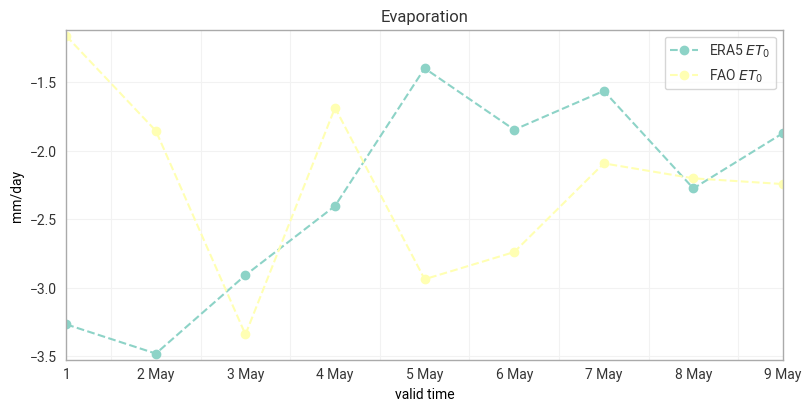

In [100]:
ekp.timeseries.line(
        et_era5, linestyle='--', marker='o', label="ERA5 $ET_0$", time_offset="12h"
    ).line(
        et_fao, linestyle='--', marker='o', label="FAO $ET_0$", time_offset="12h"
    ).ylabel(
        "mm/day"
    ).title(
        "Evaporation"
    ).xticks(frequency="D", period=True, format="%-d %b").legend().show()

In [52]:
from urllib.parse import urlencode

DATE_FROM = "2025-05-01"     # inclusive
DATE_TO   = "2025-05-10"     # exclusive  →  full year 2025

BASE_URL  = "https://data.bs.ch/api/explore/v2.1/catalog/datasets/100089"
CSV_URL   = BASE_URL + "/exports/csv"

params = {
    "where": f"timestamp >= '{DATE_FROM}' AND timestamp < '{DATE_TO}'",
    "order_by": "timestamp asc",
    "limit": -1,          # return all matching records
    "delimiter": ";",
}
url = CSV_URL + "?" + urlencode(params)

In [111]:
df = ekd.from_source("url", url).to_pandas(pandas_read_csv_kwargs={"delimiter": ";", "parse_dates": ["timestamp"], "index_col": "timestamp"}).resample('D').mean()
df['abfluss'] # in m^3 s^-1

df["depth"] = df["abfluss"] * 60*60*24 / 35878e6 * 1000 # convert from m^3/s to mm/day, using the catchment area (35878 km^2)

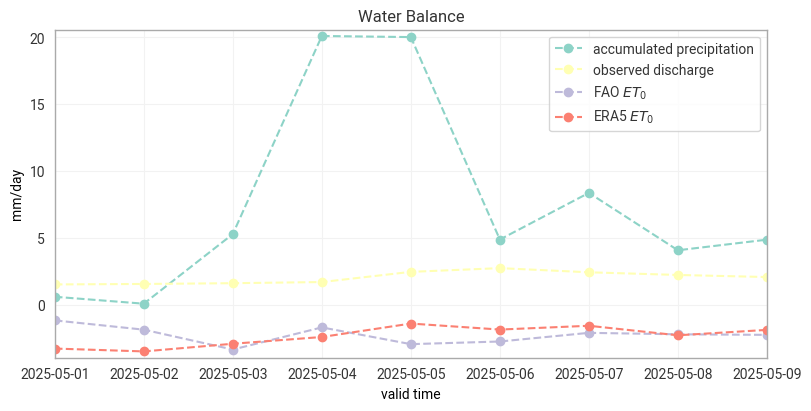

In [112]:
ekp.timeseries.line(
        daily_avg_ds['tp']*1000*24, linestyle='--', marker='o', label="accumulated precipitation"
    ).line(
        x=df['depth'].index, data=df['depth'].values, linestyle='--', marker='o', label="observed discharge"
    ).line(
        et_fao, linestyle='--', marker='o', label="FAO $ET_0$"
    ).line(
        et_era5, linestyle='--', marker='o', label="ERA5 $ET_0$"
    ).ylabel(
        "mm/day"
    ).title(
        "Water Balance"
    ).legend().show()